# Validate Tfh17 signature in Ped vs Senior TeaSeq dataset 
- related to Fig S8 C-G
- Data from Thomson et al. https://www.nature.com/articles/s41590-023-01641-8
- TEAseq data in sorted T cells from healthy children and older adult
- project Tfh17 signature from ALTRA to TEAseq data and run NMF projection based clustering

In [1]:
# load packages
import h5py
import scipy.sparse as scs
import pandas as pd
import anndata as ad
import os
import glob
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import median_abs_deviation
import scanpy as sc
import random
import celltypist
from celltypist import models
import hisepy as hp
import muon as mu
import matplotlib

/home/workspace/environment/scanpy/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# define working path
data_path = '/home/workspace/private/ra-cohort-ide/ALTRA_revision/Tfh17_followup/ped_sen/'
fig_path = '/home/workspace/private/ra-cohort-ide/ALTRA_revision/Tfh17_followup/ped_sen/figures/'
meta_path = '/home/jupyter/github/ra-longitudinal/metadata/'
output_path = '/home/workspace/private/ra-cohort-ide/ALTRA_revision/Tfh17_followup/ped_sen/output_results/'

# define a project name
proj_name = 'Tfh17_validation_ped_sen_teaseq'
# sc.set_figure_params(fig_path)
sc.settings.figdir = fig_path
sc.settings.autosave=False
sc.set_figure_params(vector_friendly=True, dpi_save=300)
matplotlib.rcParams['pdf.fonttype'] = 42

In [3]:
# Nature Publishing Group (NPG) palette
npg_color = ["#E64B35FF", "#4DBBD5FF", "#00A087FF", "#3C5488FF", "#F39B7FFF",
             "#8491B4FF", "#91D1C2FF", "#DC0000FF", "#7E6148FF", "#B09C85FF"]

# New England Journal of Medicine (NEJM) palette
nejm_color = ["#BC3C29FF", "#0072B5FF", "#E18727FF", "#20854EFF", 
              "#7876B1FF", "#6F99ADFF", "#FFDC91FF", "#EE4C97FF"]

# JAMA palette
jama_color = ["#374E55FF", "#DF8F44FF", "#00A1D5FF", "#B24745FF", 
              "#79AF97FF", "#6A6599FF", "#80796BFF"]

# Journal of Clinical Oncology (JCO) palette
jco_color = ["#0073C2FF", "#EFC000FF", "#868686FF", "#CD534CFF", 
             "#7AA6DCFF", "#003C67FF", "#8F7700FF"]

# Cluster colors
cluster_colors = ["#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72", "#B17BA6",
                  "#FF7F00", "#FDB462", "#E7298A", "#E78AC3", "#33A02C", "#B2DF8A",
                  "#55A1B1", "#8DD3C7", "#A6761D", "#E6AB02", "#7570B3", "#BEAED4",
                  "#666666", "#999999", "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3",
                  "#808000", "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00"]

# load Mudata with DSB normalization

In [4]:
cd4mem_mu = mu.read_h5mu('/home/workspace/data/ped_sen_teaseq/Ped_sen_teaseq_cd4tmem_cells_dsb_mudata.h5mu')

In [5]:
cd4mem_mu

MuData object with n_obs × n_vars = 95941 × 37566
  4 modalities
    rna:	95941 x 36601
      obs:	'orig_ident', 'nCount_RNA', 'nFeature_RNA', 'adt_qc_flag', 'adt_umis', 'batch_id', 'cell_name', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'rna_cell_uuid', 'seurat_pbmc_type', 'seurat_pbmc_type_score', 'umap_1', 'umap_2', 'well_id', 'nCount_ADT', 'nFeature_ADT', 'nCount_Tiles', 'nFeature_Tiles', 'percent_mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res_0_5', 'seurat_clusters', 'predicted_celltype_l1_score', 'predicted_celltype_l1', 'predicted_celltype_l2_score', 'predicted_celltype_l2', 'predicted_celltype_l3_score', 'predicted_celltype_l3', 'predicted_t_celltype_l1_score', 'predicted_t_celltype_l1', 'predicted_t_celltype_l2_score', 'predicted_t_celltype_l2', 'predicted_t_celltype_l3_score', 'predicted_t_celltype_l3', 'pediatric_senior', 'celltype_l0', 'predicted_labels', 'majority_voting', 'conf_score', 'over_clustering', 'predicted_score', 'predicted_labels_l2', 'predicted_score_l2', 'over_clustering_l2', 'majority_voting_l2', 'majority_percentage_l2', 'predicted_labels_l2_5', 'predicted_score_l2_5', 'over_clustering_l2_5', 'majority_voting_l2_5', 'majority_percentage_l2_5', 'final_labels', 'GEO_Accession', 'Batch', 'combined_sample_id', 'age', 'birth_year', 'tissue_type', 'library_type', 'race', 'Sex', 'subject_id', 'gating_celltype', 'NMF0_Cytotoxic', 'NMF1_Treg', 'NMF2_Th17', 'NMF3_Naive', 'NMF4_Act', 'NMF5_Th2', 'NMF6_Tfh', 'NMF7_IFN', 'NMF8_Cent_Mem', 'NMF9_Thymic_Emi', 'NMF10_Tissue', 'NMF11_Th1', 'leiden_NMF_0_5', 'leiden_NMF_1', 'barcodes', 'log10umi'
      var:	'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
      uns:	'NMF_neighbors_v1', 'batch_id_colors', 'dendrogram_leiden_NMF_0_5', 'dendrogram_leiden_NMF_1', 'final_labels_colors', 'gating_celltype_colors', 'hvg', 'leiden', 'leiden_NMF_0_5', 'leiden_NMF_0_5_colors', 'leiden_NMF_1', 'leiden_NMF_1_colors', 'log1p', 'majority_voting_colors', 'majority_voting_l2_5_colors', 'majority_voting_l3_colors', 'neighbors', 'over_clustering_colors', 'pca', 'pediatric_senior_colors', 'rank_genes_groups', 'subject_id_colors', 'umap'
      obsm:	'NMF_fac_v1', 'NMF_v1_X_umap', 'X_original_umap', 'X_pca', 'X_scVI', 'X_umap'
      varm:	'PCs'
      layers:	'counts', 'logcounts', 'transform'
      obsp:	'NMF_neighbors_v1_connectivities', 'NMF_neighbors_v1_distances', 'connectivities', 'distances'
    adt:	95941 x 40
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'barcodes', 'batch_id', 'cell_name', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'rna_cell_uuid', 'umap_1', 'umap_2', 'well_id', 'nCount_ADT', 'nFeature_ADT', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.5', 'seurat_clusters', 'predicted.t_celltype.l1.score', 'predicted.t_celltype.l1', 'predicted.t_celltype.l2.score', 'predicted.t_celltype.l2', 'predicted.t_celltype.l3.score', 'predicted.t_celltype.l3', 'pediatric_senior', 'gating_celltype', 'CMV', 'subject_id', 'age_cmv', 'wsnn_res.0.5', 'nCount_clean_adt', 'nFeature_clean_adt', 'NMF0_Cytotoxic', 'NMF1_Treg', 'NMF2_Th17', 'NMF3_Naive', 'NMF4_Act', 'NMF5_Th2', 'NMF6_Tfh', 'NMF7_IFN', 'NMF8_Cent_Mem', 'NMF9_Thymic_Emi', 'NMF10_Tissue', 'NMF11_Th1', 'leiden_NMF_0_5', 'leiden_NMF_1', 'orginal_barcodes', 'well_id_barcodes'
      var:	'features', 'mean', 'std'
      uns:	'dendrogram_leiden_NMF_0_5', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
      obsm:	'X_adt_harmony', 'X_nmfumap', 'X_pca'
      varm:	'ADT_HARMONY', 'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    tf:	95941 x 870
      obs:	'leiden_NMF_0_5'
      uns:	'dendrogram_leiden_NMF_0_5', 'leiden_NMF_0_5_colors', 'pca', 'rank_genes_groups'
      obsm:	'X_nmfumap', 'X_pca'
      varm:	'PCs'
    prot:	95941 x 55
   

## check RNA

In [6]:
rna = cd4mem_mu['rna']

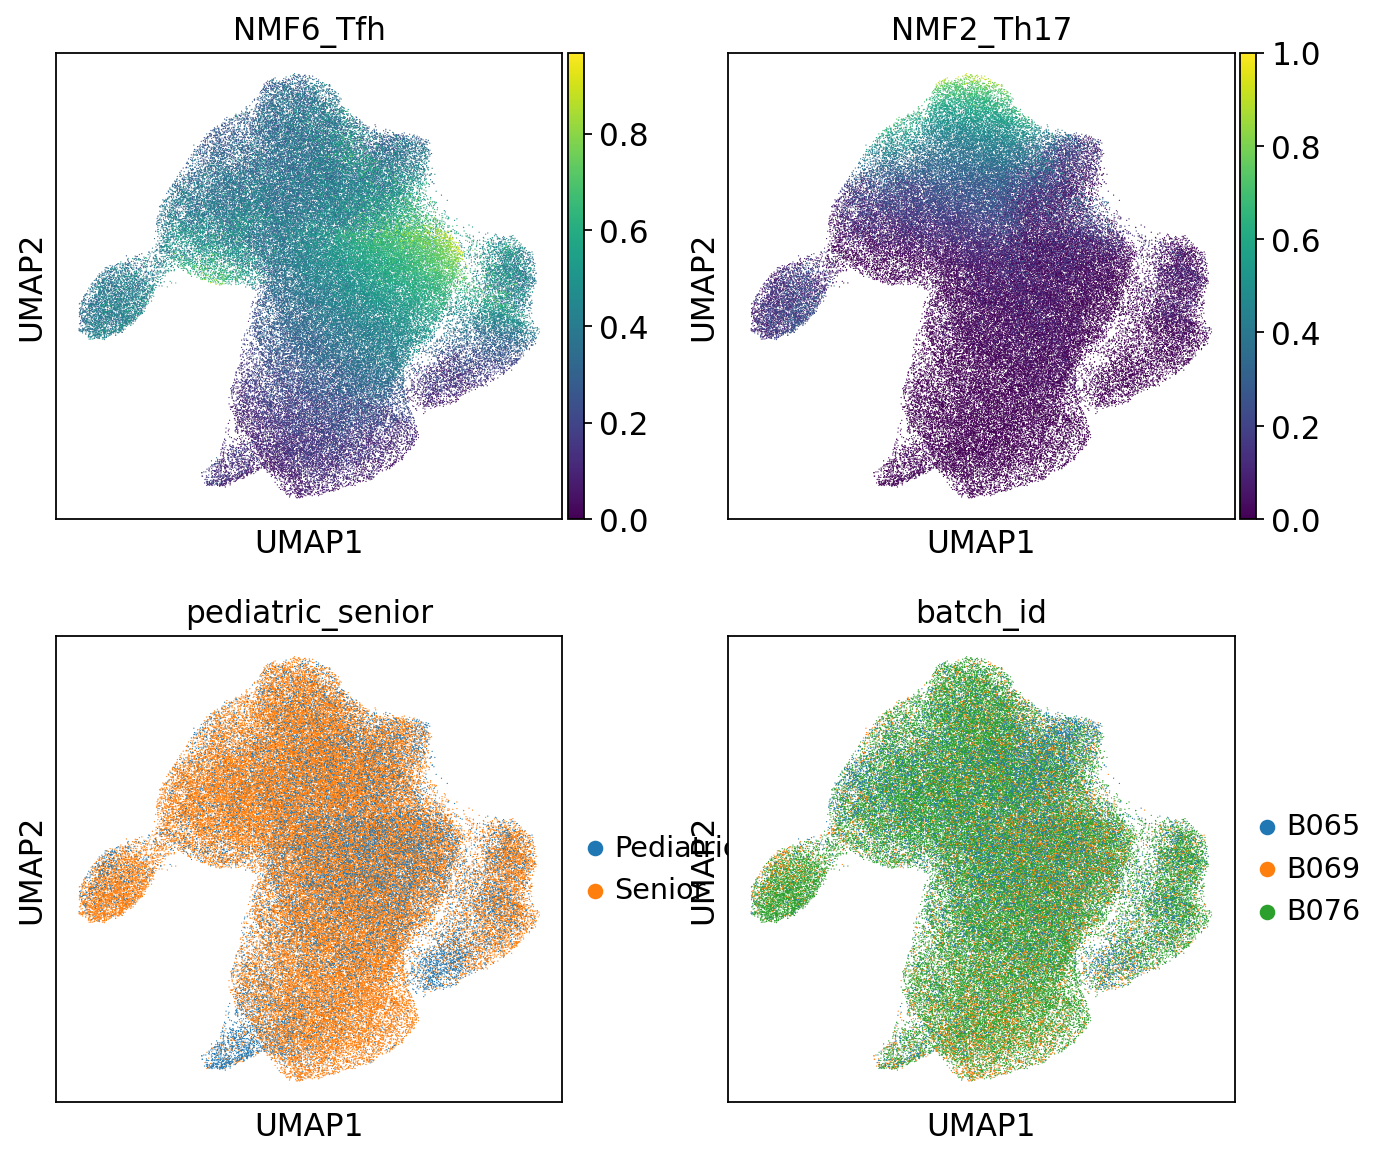

In [8]:
sc.pl.umap(
    cd4mem_mu['rna'],
    color=['NMF6_Tfh', 'NMF2_Th17',  'pediatric_senior', 'batch_id'], ncols=2,
    save=  proj_name+'cd4mem_NMF6_Tfh_nmf_umap.png'
)

### plot fig S8C

maxp pruned
cmap pruned
kern dropped
post pruned
FFTM dropped
GPOS pruned
GSUB pruned
glyf pruned
Added gid0 to subset
Added first four glyphs to subset
Closing glyph list over 'GSUB': 13 glyphs before
Glyph names: ['.notdef', '.null', 'eight', 'five', 'four', 'nonmarkingreturn', 'one', 'seven', 'six', 'space', 'three', 'two', 'zero']
Glyph IDs:   [0, 1, 2, 3, 19, 20, 21, 22, 23, 24, 25, 26, 27]
Closed glyph list over 'GSUB': 13 glyphs after
Glyph names: ['.notdef', '.null', 'eight', 'five', 'four', 'nonmarkingreturn', 'one', 'seven', 'six', 'space', 'three', 'two', 'zero']
Glyph IDs:   [0, 1, 2, 3, 19, 20, 21, 22, 23, 24, 25, 26, 27]
Closing glyph list over 'glyf': 13 glyphs before
Glyph names: ['.notdef', '.null', 'eight', 'five', 'four', 'nonmarkingreturn', 'one', 'seven', 'six', 'space', 'three', 'two', 'zero']
Glyph IDs:   [0, 1, 2, 3, 19, 20, 21, 22, 23, 24, 25, 26, 27]
Closed glyph list over 'glyf': 13 glyphs after
Glyph names: ['.notdef', '.null', 'eight', 'five', 'four', 'nonm

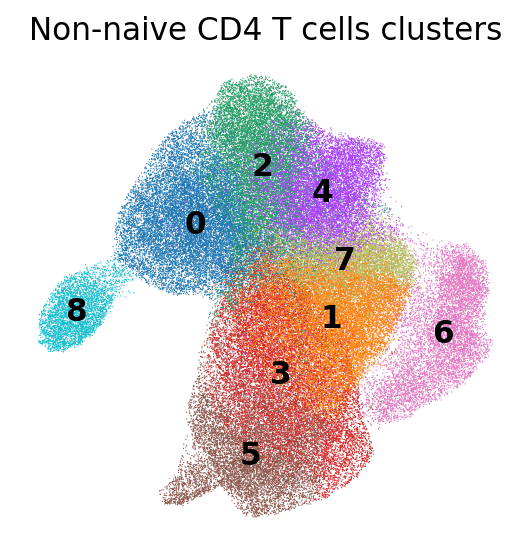

In [10]:
sc.pl.umap(
    cd4mem_mu['rna'], frameon=False,
    color=['leiden_NMF_0_5'],legend_loc='on data', title='Non-naive CD4 T cells clusters',
    save=  proj_name+'cd4mem_leiden_NMF_0_5_umap.pdf'
)

### plot fig S8E

maxp pruned
cmap pruned
kern dropped
post pruned
FFTM dropped
GPOS pruned
GSUB pruned
glyf pruned
Added gid0 to subset
Added first four glyphs to subset
Closing glyph list over 'MATH': 51 glyphs before
Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'X', 'Y', 'a', 'c', 'e', 'eight', 'f', 'five', 'four', 'g', 'i', 'l', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'percent', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'x', 'zero']
Glyph IDs:   [0, 1, 2, 3, 8, 11, 12, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 36, 37, 38, 39, 40, 41, 42, 44, 46, 47, 48, 49, 50, 51, 53, 54, 55, 59, 60, 68, 70, 72, 73, 74, 76, 79, 81, 82, 83, 85, 86, 87, 88, 91]
Closed glyph list over 'MATH': 57 glyphs after
Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'X', 'Y', 'a', 'c', 'e', 'eight', 'f', 'five', 'four', 'g', 'i', '

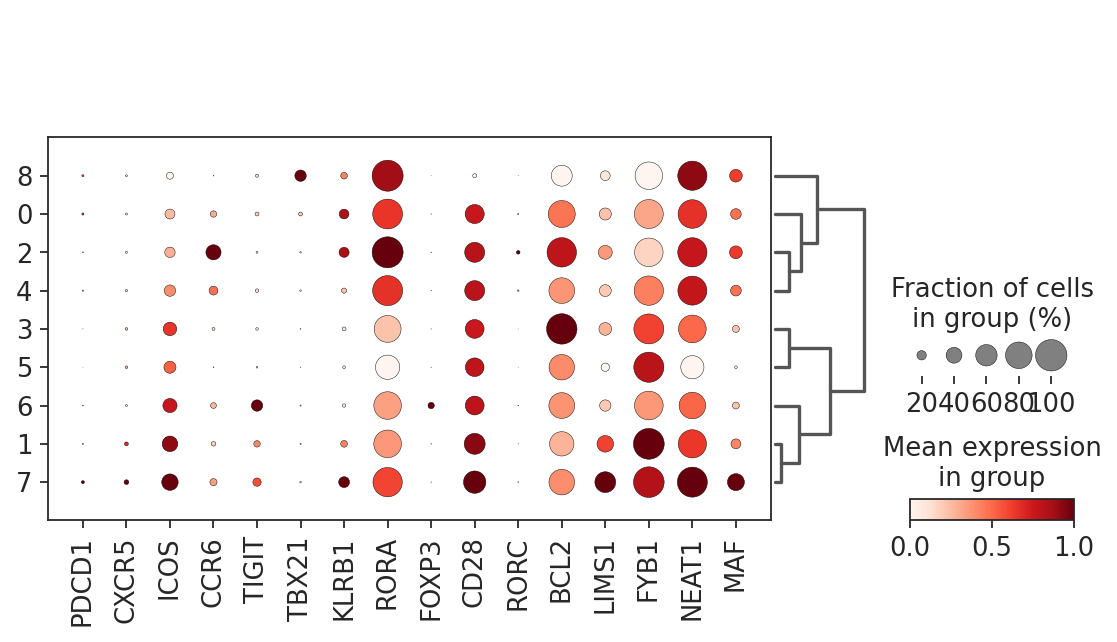

In [19]:
# Plot the dotplot for Thf17 marker genes
gene_oi = pd.Series(['PDCD1', 'CXCR5', 'ICOS', 'CCR6', 'TIGIT', 'TBX21', 'KLRB1', 'RORA', 'FOXP3', 'CD28',
     'RORC', 'BCL2', 'LIMS1', 'FYB1', 'NEAT1', 'MAF'])
gene_oi = gene_oi[gene_oi.isin(cd4mem_mu.var.index)].tolist()

sc.pl.dotplot(
    cd4mem_mu['rna'], 
   gene_oi, use_raw=False,
    groupby='leiden_NMF_0_5', 
    standard_scale='var', 
    #swap_axes=True,
    dendrogram=True,
    save = proj_name+'leiden_NMF_0_5_marker_genes_dotplot.pdf',
)

### plot fig S8D
- calcualte the C3 gene socres

In [13]:
# mapping C3 genes
c3_genes = [
    "LIMS1", "FYB1", "KLRB1", "MAF", "NEAT1", "TBC1D4", "ITGA4",
    "SLFN5", "PTPRC", "TMSB4X", "PASK", "TCF7", "NAP1L1", "PPP2R5C",
    "ETS1", "IKZF3", "AQP3", "RIPOR2", "RPL23", "TPR", "ARGLU1",
    "DDX17", "TLK1", "TRIB2", "TSHZ2", "GPR183", "ITM2A", "CD28",
    "MALAT1", "RNASET2", "SEPT6"
]

In [23]:
sc.tl.score_genes(rna, gene_list=c3_genes[0:10], score_name='c3_score')

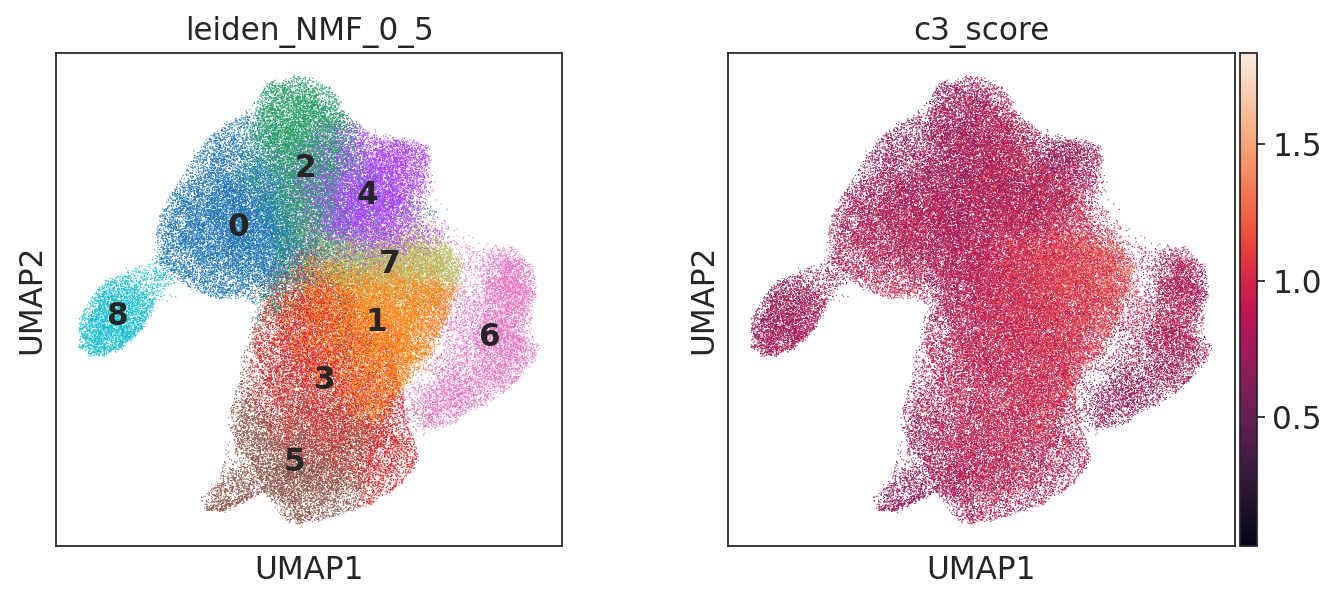

In [21]:
sc.pl.umap(
    rna,
    color=['leiden_NMF_0_5', 'c3_score'],legend_loc='on data',
    save=  proj_name+'cd4mem_leiden_NMF_0_5_c3_score_umap.png'
)

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


maxp pruned
cmap pruned
kern dropped
post pruned
FFTM dropped
GPOS pruned
GSUB pruned
glyf pruned
Added gid0 to subset
Added first four glyphs to subset
Closing glyph list over 'MATH': 28 glyphs before
Glyph names: ['.notdef', '.null', 'F', 'M', 'N', 'c', 'd', 'e', 'eight', 'five', 'four', 'i', 'l', 'minus', 'n', 'nonmarkingreturn', 'o', 'one', 'period', 'r', 's', 'seven', 'six', 'space', 'three', 'two', 'underscore', 'zero']
Glyph IDs:   [0, 1, 2, 3, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 41, 48, 49, 66, 70, 71, 72, 76, 79, 81, 82, 85, 86, 3228]
Closed glyph list over 'MATH': 28 glyphs after
Glyph names: ['.notdef', '.null', 'F', 'M', 'N', 'c', 'd', 'e', 'eight', 'five', 'four', 'i', 'l', 'minus', 'n', 'nonmarkingreturn', 'o', 'one', 'period', 'r', 's', 'seven', 'six', 'space', 'three', 'two', 'underscore', 'zero']
Glyph IDs:   [0, 1, 2, 3, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 41, 48, 49, 66, 70, 71, 72, 76, 79, 81, 82, 85, 86, 3228]
Closing glyph list over 'GSUB': 28 glyphs befor

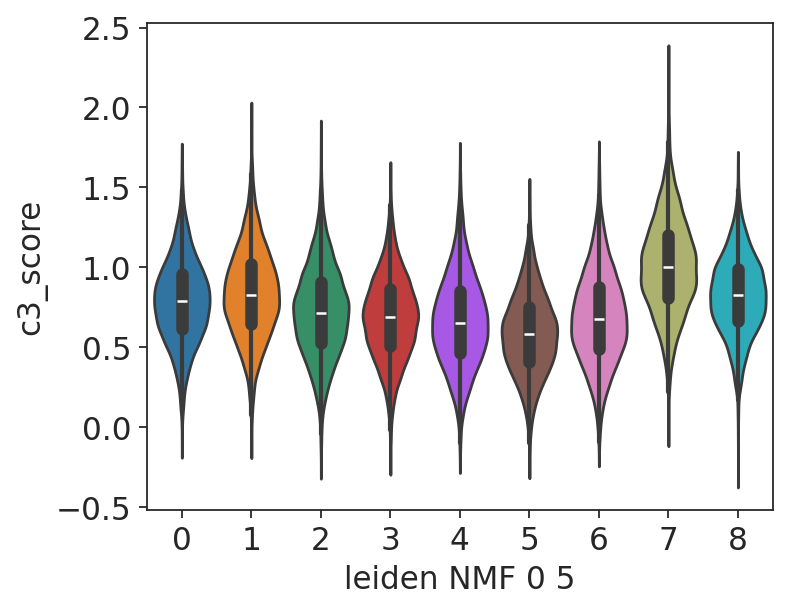

In [24]:
sns.set_style("ticks")
with plt.rc_context({"figure.figsize": (5, 4)}):
    sc.pl.violin(rna, keys='c3_score', groupby='leiden_NMF_0_5', 
             save='leiden_NMF_0_5_C3_gene_scores.pdf',
        stripplot=False,
        show=True,
        inner='box')


In [25]:
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import kruskal
import scikit_posthocs as sp
df = rna.obs[['c3_score', 'leiden_NMF_0_5']].dropna().copy().rename(columns={'leiden_NMF_0_5':'leiden'})


# Group the scores by cluster
groups = [group['c3_score'].values for _, group in df.groupby('leiden')]

# Run Kruskal-Wallis test
stat, p_value = kruskal(*groups)
print(f"Kruskal-Wallis H-test statistic = {stat}, p = {p_value}")

# If significant, run pairwise Dunn's test
if p_value < 0.05:
    dunn_result = sp.posthoc_dunn(df, val_col='c3_score', group_col='leiden', p_adjust='bonferroni')
    print("\nPairwise Dunn's Test (Bonferroni-corrected p-values):")
    print(dunn_result.round(4))

Kruskal-Wallis H-test statistic = 11270.60296215926, p = 0.0

Pairwise Dunn's Test (Bonferroni-corrected p-values):
     0    1    2    3    4    5    6    7    8
0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
1  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0
2  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0
3  0.0  0.0  0.0  1.0  0.0  0.0  1.0  0.0  0.0
4  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0
5  0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0
6  0.0  0.0  0.0  1.0  0.0  0.0  1.0  0.0  0.0
7  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0
8  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0


## chcek protein

In [14]:
cd4mem_mu

MuData object with n_obs × n_vars = 95941 × 37566
  4 modalities
    rna:	95941 x 36601
      obs:	'orig_ident', 'nCount_RNA', 'nFeature_RNA', 'adt_qc_flag', 'adt_umis', 'batch_id', 'cell_name', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'rna_cell_uuid', 'seurat_pbmc_type', 'seurat_pbmc_type_score', 'umap_1', 'umap_2', 'well_id', 'nCount_ADT', 'nFeature_ADT', 'nCount_Tiles', 'nFeature_Tiles', 'percent_mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res_0_5', 'seurat_clusters', 'predicted_celltype_l1_score', 'predicted_celltype_l1', 'predicted_celltype_l2_score', 'predicted_celltype_l2', 'predicted_celltype_l3_score', 'predicted_celltype_l3', 'predicted_t_celltype_l1_score', 'predicted_t_celltype_l1', 'predicted_t_celltype_l2_score', 'predicted_t_celltype_l2', 'predicted_t_celltype_l3_score', 'predicted_t_celltype_l3', 'pediatric_senior', 'celltype_l0', 'predicted_labels', 'majority_voting', 'conf_score', 'over_clustering', 'predicted_score', 'predicted_labels_l2', 'predicted_score_l2', 'over_clustering_l2', 'majority_voting_l2', 'majority_percentage_l2', 'predicted_labels_l2_5', 'predicted_score_l2_5', 'over_clustering_l2_5', 'majority_voting_l2_5', 'majority_percentage_l2_5', 'final_labels', 'GEO_Accession', 'Batch', 'combined_sample_id', 'age', 'birth_year', 'tissue_type', 'library_type', 'race', 'Sex', 'subject_id', 'gating_celltype', 'NMF0_Cytotoxic', 'NMF1_Treg', 'NMF2_Th17', 'NMF3_Naive', 'NMF4_Act', 'NMF5_Th2', 'NMF6_Tfh', 'NMF7_IFN', 'NMF8_Cent_Mem', 'NMF9_Thymic_Emi', 'NMF10_Tissue', 'NMF11_Th1', 'leiden_NMF_0_5', 'leiden_NMF_1', 'barcodes', 'log10umi'
      var:	'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
      uns:	'NMF_neighbors_v1', 'batch_id_colors', 'dendrogram_leiden_NMF_0_5', 'dendrogram_leiden_NMF_1', 'final_labels_colors', 'gating_celltype_colors', 'hvg', 'leiden', 'leiden_NMF_0_5', 'leiden_NMF_0_5_colors', 'leiden_NMF_1', 'leiden_NMF_1_colors', 'log1p', 'majority_voting_colors', 'majority_voting_l2_5_colors', 'majority_voting_l3_colors', 'neighbors', 'over_clustering_colors', 'pca', 'pediatric_senior_colors', 'rank_genes_groups', 'subject_id_colors', 'umap'
      obsm:	'NMF_fac_v1', 'NMF_v1_X_umap', 'X_original_umap', 'X_pca', 'X_scVI', 'X_umap'
      varm:	'PCs'
      layers:	'counts', 'logcounts', 'transform'
      obsp:	'NMF_neighbors_v1_connectivities', 'NMF_neighbors_v1_distances', 'connectivities', 'distances'
    adt:	95941 x 40
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'barcodes', 'batch_id', 'cell_name', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'rna_cell_uuid', 'umap_1', 'umap_2', 'well_id', 'nCount_ADT', 'nFeature_ADT', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.5', 'seurat_clusters', 'predicted.t_celltype.l1.score', 'predicted.t_celltype.l1', 'predicted.t_celltype.l2.score', 'predicted.t_celltype.l2', 'predicted.t_celltype.l3.score', 'predicted.t_celltype.l3', 'pediatric_senior', 'gating_celltype', 'CMV', 'subject_id', 'age_cmv', 'wsnn_res.0.5', 'nCount_clean_adt', 'nFeature_clean_adt', 'NMF0_Cytotoxic', 'NMF1_Treg', 'NMF2_Th17', 'NMF3_Naive', 'NMF4_Act', 'NMF5_Th2', 'NMF6_Tfh', 'NMF7_IFN', 'NMF8_Cent_Mem', 'NMF9_Thymic_Emi', 'NMF10_Tissue', 'NMF11_Th1', 'leiden_NMF_0_5', 'leiden_NMF_1', 'orginal_barcodes', 'well_id_barcodes'
      var:	'features', 'mean', 'std'
      uns:	'dendrogram_leiden_NMF_0_5', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
      obsm:	'X_adt_harmony', 'X_nmfumap', 'X_pca'
      varm:	'ADT_HARMONY', 'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    tf:	95941 x 870
      obs:	'leiden_NMF_0_5'
      uns:	'dendrogram_leiden_NMF_0_5', 'leiden_NMF_0_5_colors', 'pca', 'rank_genes_groups'
      obsm:	'X_nmfumap', 'X_pca'
      varm:	'PCs'
    prot:	95941 x 55
   

In [19]:
prot = cd4mem_mu['prot']
prot

AnnData object with n_obs × n_vars = 95941 × 55
    obs: 'well_id_barcodes', 'orginal_barcodes', 'well_id', 'batch_id'
    layers: 'counts', 'dsb'

In [20]:
prot.X = prot.layers['dsb'].copy()

In [21]:
prot.obsm['X_nmfumap'] = cd4mem_mu['rna'].obsm['X_umap'].copy()
prot.obs['leiden_NMF_0_5'] = cd4mem_mu['rna'].obs['leiden_NMF_0_5'].astype('str').astype('category').copy()

In [22]:
prot.X

array([[ 7.85931134e+00,  2.97244573e+00,  8.53790642e+00, ...,
         8.89292493e+00,  2.43394384e+00, -8.92244205e-02],
       [ 4.44422864e+00,  2.69974518e+00,  9.36185128e+00, ...,
         1.32521337e+01,  1.22654623e-01, -7.91408783e-02],
       [ 7.29612405e+00,  3.80017366e+00,  1.02024253e+01, ...,
         8.10235867e+00,  2.96123689e+00, -4.55080603e-02],
       ...,
       [-5.92698259e-01,  1.69295299e+00, -3.17815824e-01, ...,
        -8.25541407e-01,  4.48510637e-01,  3.37581448e-01],
       [ 1.48664858e+00,  1.54644815e+00, -1.26829935e-02, ...,
         5.41731346e-01,  4.48368978e-01,  3.34398670e-01],
       [ 4.91183967e-01,  2.09633257e+00,  9.65818068e-01, ...,
        -1.15766636e-01,  4.45301890e-01,  2.65487968e-01]])

In [23]:
prot.layers['dsb']

array([[ 7.85931134e+00,  2.97244573e+00,  8.53790642e+00, ...,
         8.89292493e+00,  2.43394384e+00, -8.92244205e-02],
       [ 4.44422864e+00,  2.69974518e+00,  9.36185128e+00, ...,
         1.32521337e+01,  1.22654623e-01, -7.91408783e-02],
       [ 7.29612405e+00,  3.80017366e+00,  1.02024253e+01, ...,
         8.10235867e+00,  2.96123689e+00, -4.55080603e-02],
       ...,
       [-5.92698259e-01,  1.69295299e+00, -3.17815824e-01, ...,
        -8.25541407e-01,  4.48510637e-01,  3.37581448e-01],
       [ 1.48664858e+00,  1.54644815e+00, -1.26829935e-02, ...,
         5.41731346e-01,  4.48368978e-01,  3.34398670e-01],
       [ 4.91183967e-01,  2.09633257e+00,  9.65818068e-01, ...,
        -1.15766636e-01,  4.45301890e-01,  2.65487968e-01]])

In [35]:
prot.raw = prot.copy()

In [36]:
sc.pp.scale(prot)

In [37]:
sc.tl.pca(prot)

In [38]:
sc.pp.neighbors(prot)
sc.tl.umap(prot, random_state=1)

In [ ]:
cd4mem_mu.update()

In [39]:
prot

AnnData object with n_obs × n_vars = 95941 × 55
    obs: 'well_id_barcodes', 'orginal_barcodes', 'well_id', 'batch_id', 'leiden_NMF_0_5', 'Tph_gate'
    var: 'mean', 'std'
    uns: 'rank_genes_groups', 'pca', 'dendrogram_leiden_NMF_0_5', 'leiden_NMF_0_5_colors', 'neighbors', 'umap'
    obsm: 'X_nmfumap', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'dsb'
    obsp: 'distances', 'connectivities'

In [16]:
prot.var_names

Index(['CD152', 'CD194', 'CD196', 'CD244', 'CD26', 'CD294', 'CD49d', 'CD278',
       'CD11b', 'CD11c', 'CD127', 'CD16', 'CD172a', 'CD185', 'CD21', 'CD25',
       'CD27', 'CD279', 'CD304', 'CD38', 'CD39', 'CD4', 'CD56', 'CD71', 'CD8a',
       'CD86', 'TCR_Valpha7_2', 'CD103', 'CD57', 'CD69', 'CD192', 'CD45RA',
       'CD95', 'HLA_DR', 'KLRG1', 'CD137', 'CD161', 'CD183', 'CD85j', 'CX3CR1',
       'CD366', 'CD80', 'CD197', 'CD28', 'CD40', 'CD45RO', 'TCRab', 'TCRgd',
       'TIGIT', 'CD134', 'CD154', 'TCR_Valpha24_Jalpha18', 'CD24', 'CD319',
       'IgG1_K_Isotype_Control'],
      dtype='object')

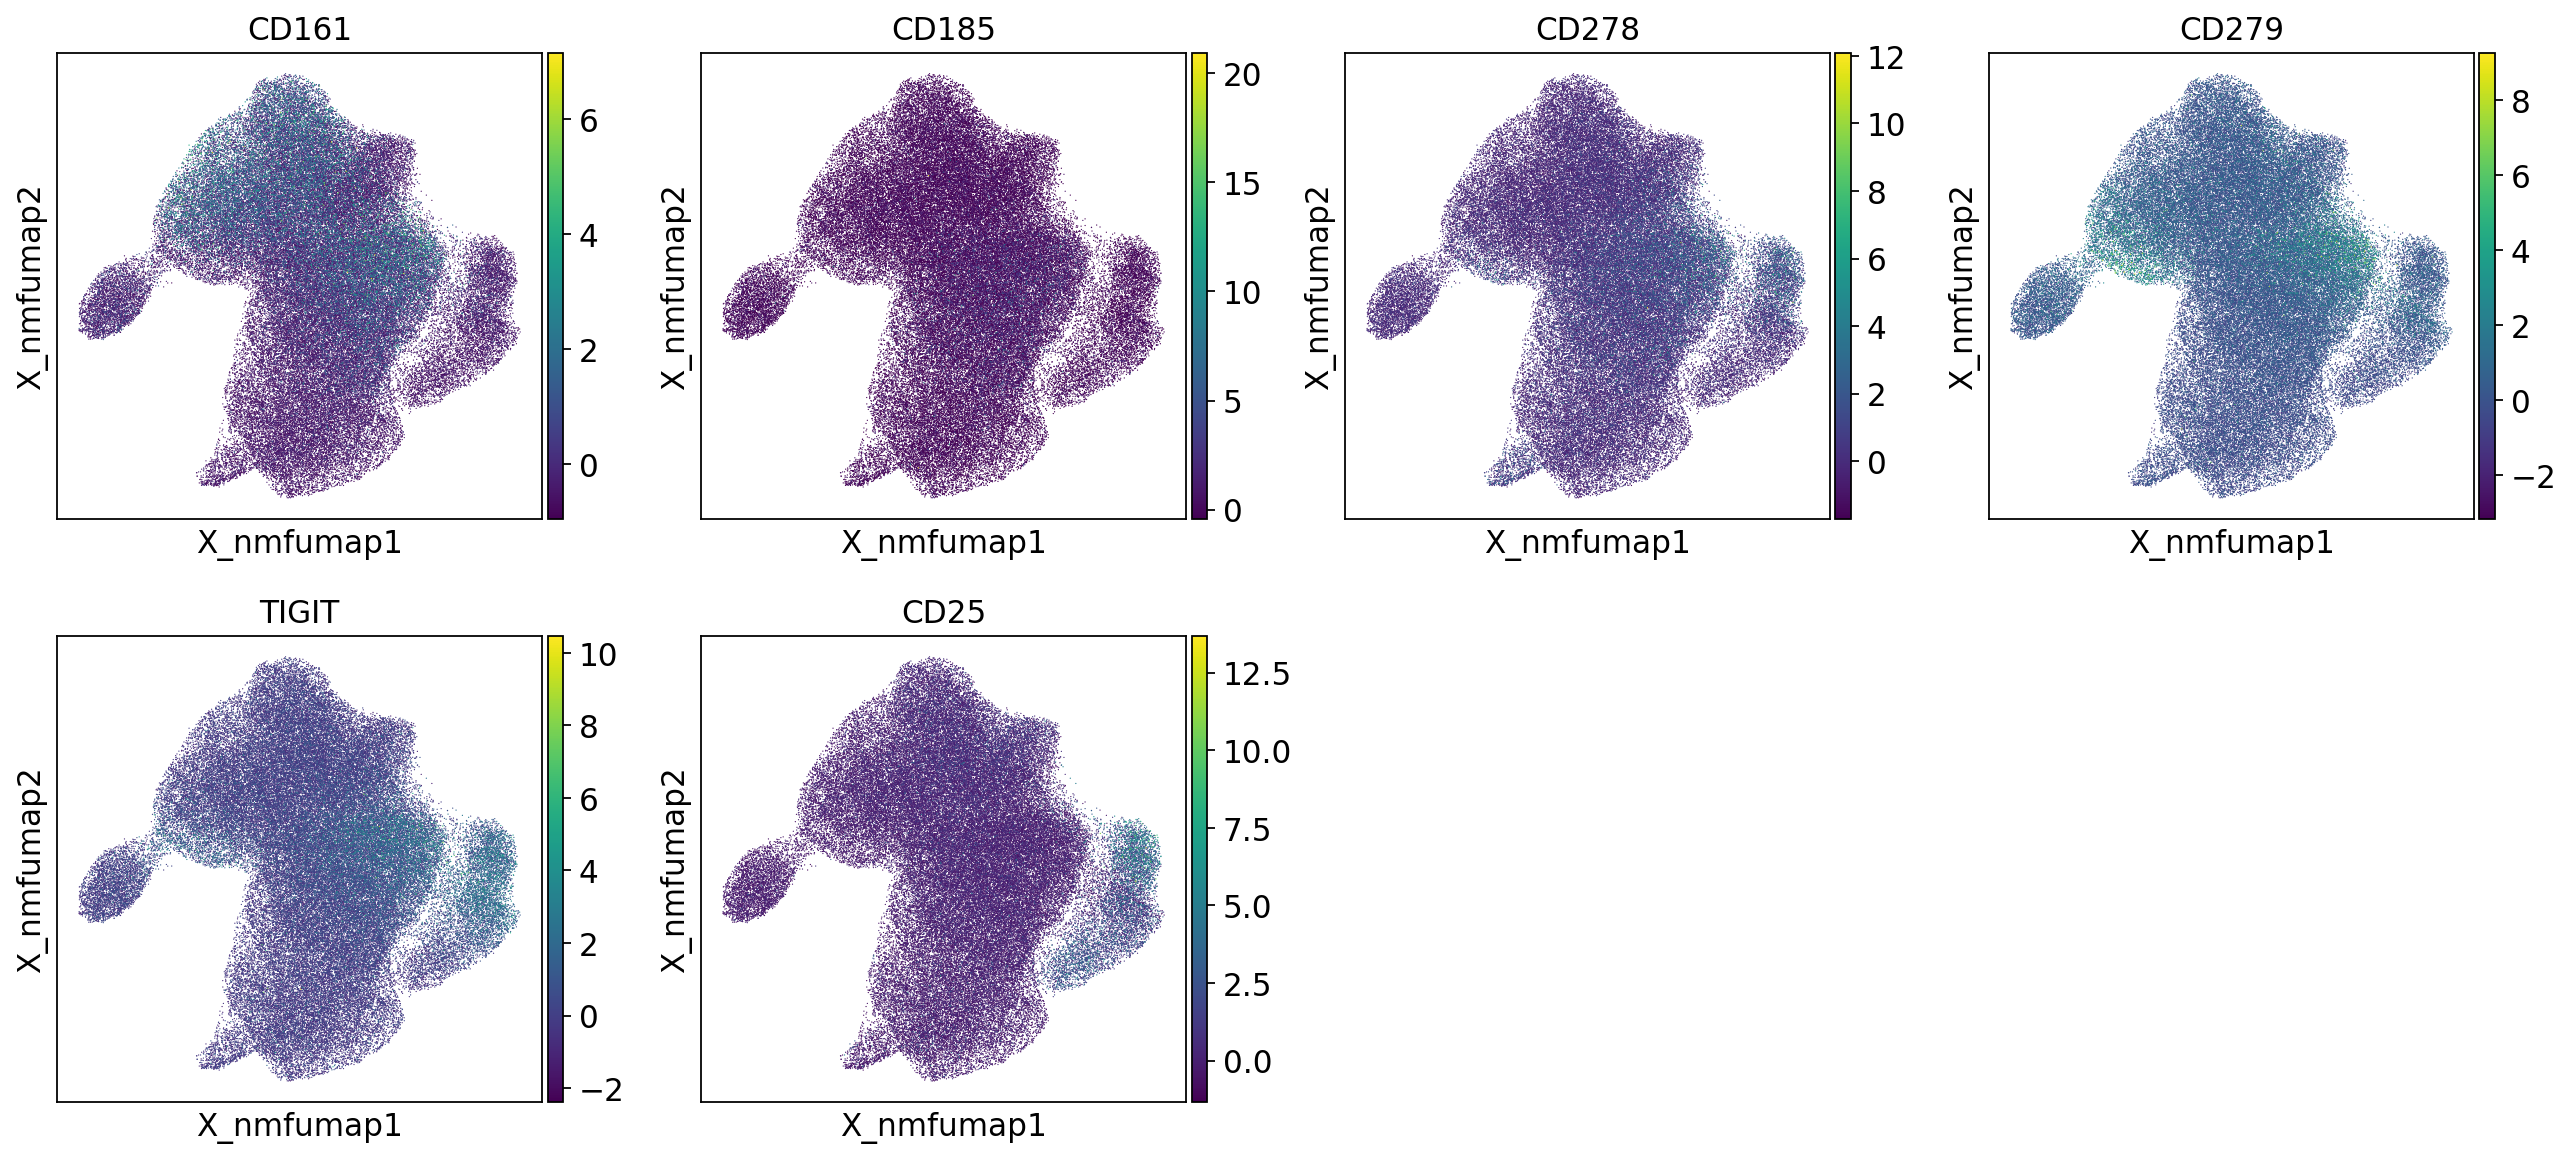

In [42]:
sc.pl.embedding(adata=prot, basis = 'X_nmfumap',  use_raw=False,
    color=[ 'CD161', 'CD185', 'CD278', 'CD279', 'TIGIT', 'CD25'], 
                vmin='p1', vmax='p99', 
    save=  proj_name+'cd4mem_NMF6_Tfh_nmf_adt_umap.png'
)

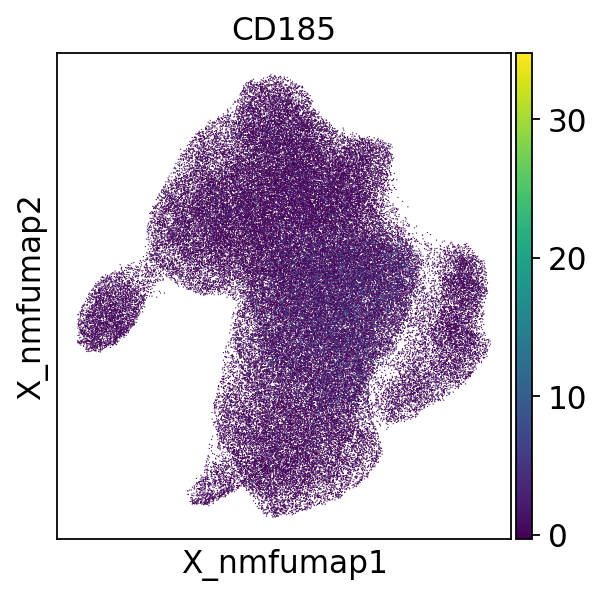

In [65]:
sc.pl.embedding(adata=prot, basis = 'X_nmfumap',  use_raw=True,
    color=[ 'CD185'], 
             #   vmin='p1', vmax='p99', 
    save=  proj_name+'cd4mem_NMF6_Tfh_nmf_CD185_adt_umap.png'
)

In [43]:
# Obtain cluster-specific differentially expressed genes
sc.tl.rank_genes_groups(prot, groupby="leiden_NMF_0_5",
                        use_raw=False, method="wilcoxon")

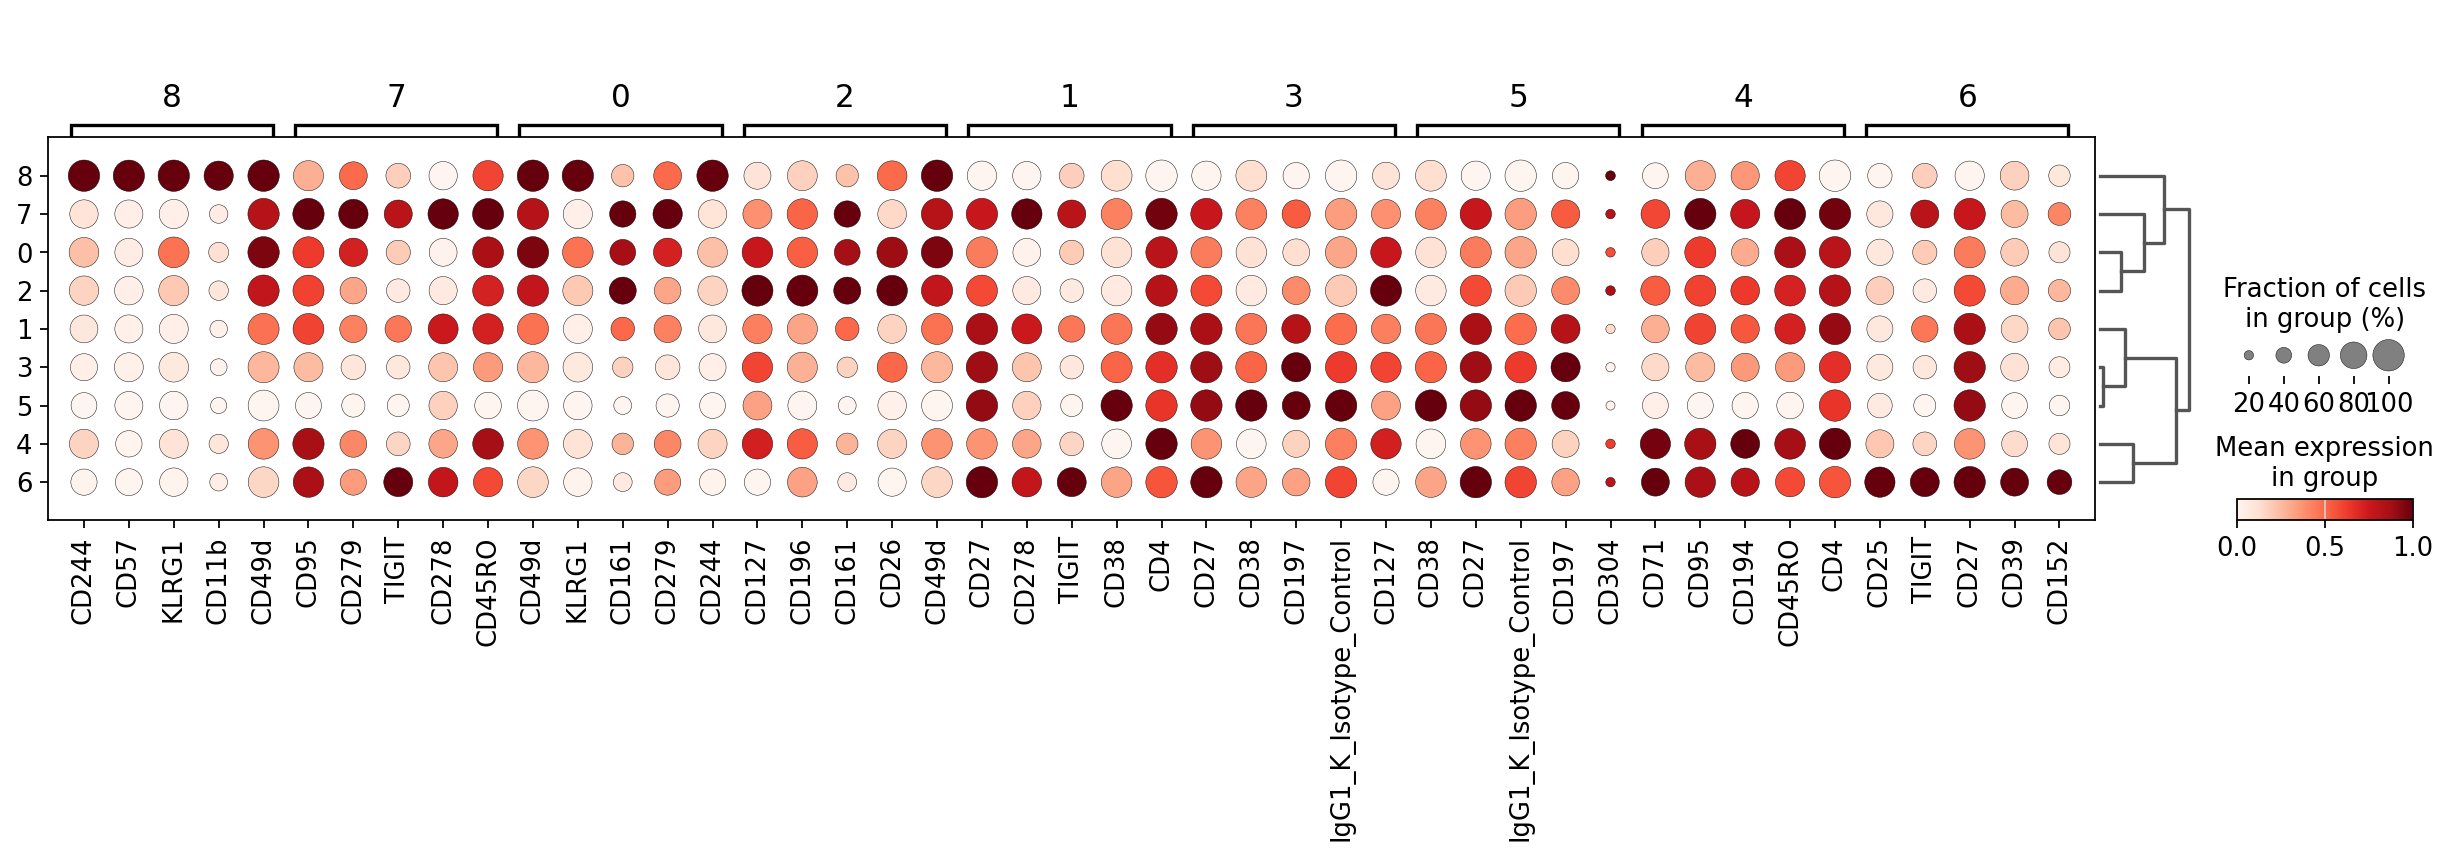

In [44]:
sc.pl.rank_genes_groups_dotplot(
    prot, groupby="leiden_NMF_0_5", 
    standard_scale="var",use_raw=True, n_genes= 5, 
    save = proj_name+'leiden_NMF_0_5_marker_adt_dotplot.png'
)

### plot FigS8G
- biaxial gates for PD1 and ICOS

In [75]:
def plot_marker_contour_highlight(
    adata,
    marker_x,
    marker_y,
    cluster_key,
    highlight_cluster,
    output_file=None,
    palette=None
):
    """
    Plots a scatter + contour plot of two markers with a specific cluster highlighted.

    Parameters:
        adata (AnnData): The protein modality of a MuData or AnnData object.
        marker_x (str): Name of the marker to plot on the x-axis.
        marker_y (str): Name of the marker to plot on the y-axis.
        cluster_key (str): Key in `.obs` indicating cluster assignments.
        highlight_cluster (str or int): The cluster to highlight.
        output_file (str, optional): Path to save the figure. If None, figure is not saved.
        palette (dict, optional): Dictionary with colors for 'highlight' and 'other' groups.
                                  Example: {'highlight': '#E64B35', 'other': 'lightgrey'}
    """
    import contextlib
    # Set default palette if none provided
    if palette is None:
        palette = {
            'highlight': '#E64B35',  # red
            'other': 'lightgrey'
        }

    # Extract data
    df = adata.obs.copy()
    df[marker_x] = adata[:, marker_x].X.toarray().flatten()
    df[marker_y] = adata[:, marker_y].X.toarray().flatten()
    df['cluster'] = adata.obs[cluster_key].astype(str)

    highlight_label = f"Cluster {highlight_cluster}"
    df['highlight'] = df['cluster'].apply(lambda x: highlight_label if x == str(highlight_cluster) else 'Other')

    # Final color palette used by seaborn
    sns_palette = {
        highlight_label: palette['highlight'],
        'Other': palette['other']
    }
    # make color for contour plot
    palette2 = {
    highlight_label: '#E64B35',  # red or any highlight color
    'Other': "#0072B5FF"
    }
    # Plot
    plt.figure(figsize=(8, 6))

    # Contour of highlighted cluster only
    sns.kdeplot(
        data=df,
        x=marker_x,
        y=marker_y,
        levels=5,
        hue='highlight',
        palette=palette2,
        linewidths=1.5,
        fill=False,
        common_norm=False,  # allow each group to have its own normalization
        thresh=0.1            # include contours even at very low density
    )

    # Scatter plot
    sns.scatterplot(
        data=df,
        x=marker_x,
        y=marker_y,
        hue='highlight',
        palette=sns_palette,
        s=10,
        alpha=0.7,
        linewidth=0
    )

    plt.title(f"{marker_x} vs {marker_y} - Highlight {highlight_label}")
    plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    if output_file:
        # Suppress stdout temporarily while saving
        with open(os.devnull, 'w') as fnull:
            with contextlib.redirect_stdout(fnull):
                plt.savefig(output_file, dpi=300)
    plt.show()

maxp pruned
cmap pruned
kern dropped
post pruned
FFTM dropped
GPOS pruned
GSUB pruned
glyf pruned
Added gid0 to subset
Added first four glyphs to subset
Closing glyph list over 'MATH': 28 glyphs before
Glyph names: ['.notdef', '.null', 'C', 'D', 'H', 'O', 'e', 'eight', 'five', 'g', 'h', 'hyphen', 'i', 'l', 'minus', 'nine', 'nonmarkingreturn', 'one', 'period', 'r', 's', 'seven', 'space', 't', 'two', 'u', 'v', 'zero']
Glyph IDs:   [0, 1, 2, 3, 16, 17, 19, 20, 21, 24, 26, 27, 28, 38, 39, 43, 50, 72, 74, 75, 76, 79, 85, 86, 87, 88, 89, 3228]
Closed glyph list over 'MATH': 28 glyphs after
Glyph names: ['.notdef', '.null', 'C', 'D', 'H', 'O', 'e', 'eight', 'five', 'g', 'h', 'hyphen', 'i', 'l', 'minus', 'nine', 'nonmarkingreturn', 'one', 'period', 'r', 's', 'seven', 'space', 't', 'two', 'u', 'v', 'zero']
Glyph IDs:   [0, 1, 2, 3, 16, 17, 19, 20, 21, 24, 26, 27, 28, 38, 39, 43, 50, 72, 74, 75, 76, 79, 85, 86, 87, 88, 89, 3228]
Closing glyph list over 'GSUB': 28 glyphs before
Glyph names: ['.no

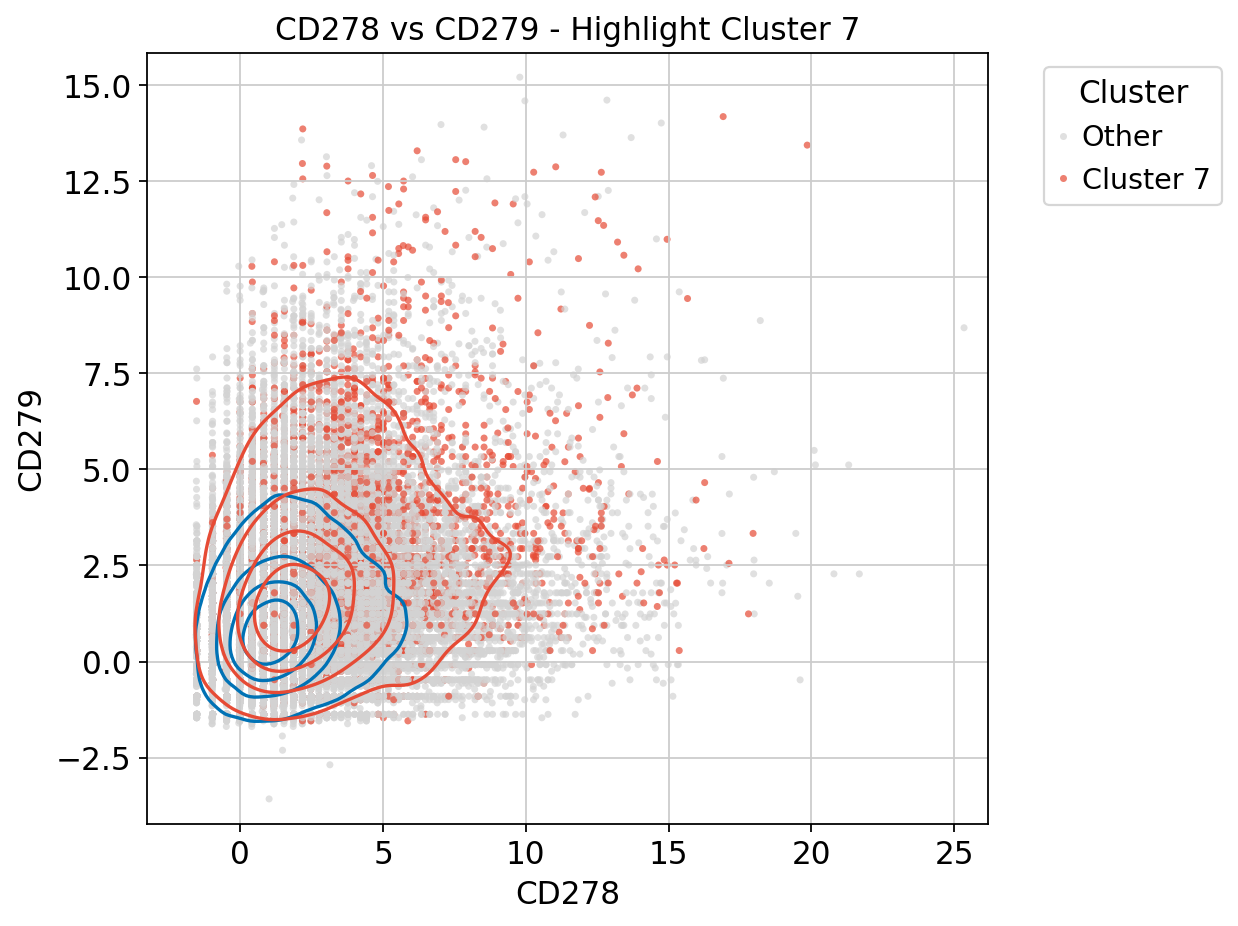

In [76]:
plot_marker_contour_highlight(
    adata=prot,
    marker_x='CD278',
    marker_y='CD279',
    cluster_key='leiden_NMF_0_5',
    highlight_cluster='7', 
    palette={'highlight': '#E64B35', 'other': 'lightgrey'},
    output_file=fig_path + proj_name + 'CD278_CD279_cluster7.pdf'
)

### plot Fig S8F

maxp pruned
cmap pruned
kern dropped
post pruned
FFTM dropped
GPOS pruned
GSUB pruned
glyf pruned
Added gid0 to subset
Added first four glyphs to subset
Closing glyph list over 'MATH': 40 glyphs before
Glyph names: ['.notdef', '.null', 'C', 'D', 'F', 'G', 'I', 'M', 'T', 'a', 'c', 'e', 'eight', 'f', 'five', 'four', 'g', 'i', 'l', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'percent', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'x', 'zero']
Glyph IDs:   [0, 1, 2, 3, 8, 11, 12, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 38, 39, 41, 42, 44, 48, 55, 68, 70, 72, 73, 74, 76, 79, 81, 82, 83, 85, 86, 87, 88, 91]
Closed glyph list over 'MATH': 46 glyphs after
Glyph names: ['.notdef', '.null', 'C', 'D', 'F', 'G', 'I', 'M', 'T', 'a', 'c', 'e', 'eight', 'f', 'five', 'four', 'g', 'i', 'l', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'percent', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two'

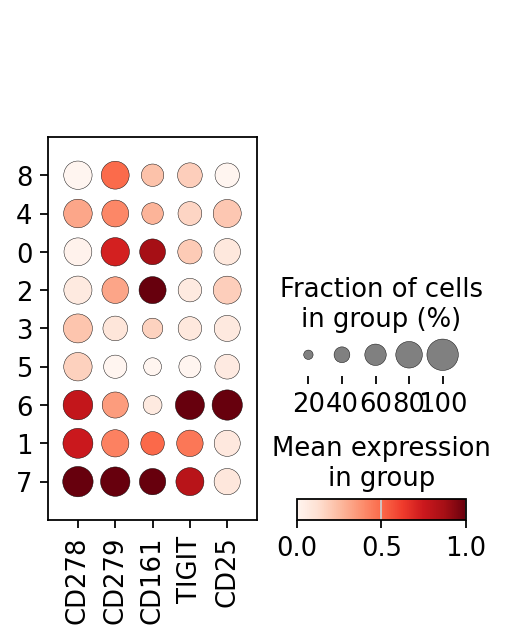

In [69]:
# Plot the dotplot for the selected clusters
# sc.tl.dendrogram(cd4mem_tea_adt, groupby='scvi_leiden_0_6')
sc.pl.dotplot(
    prot, 
   ['CD278', 'CD279', 'CD161', 'TIGIT', 'CD25'], use_raw=True,
    groupby='leiden_NMF_0_5', 
    standard_scale='var',
    categories_order = ['8', '4', '0', '2', '3', '5', '6', '1', '7'],
    #swap_axes=True,
    dendrogram=False,
    save = proj_name+'_cd4mem_leiden_NMF_0_5_tph_dotplot.pdf',
)

In [102]:
cd4mem_mu.update()

In [103]:
cd4mem_mu.write(output_path + proj_name + 'cd4tmem_cells_tf_mudata.h5mu')